# MLOps Training 2026/2027 — Task 2
## Notebook 4 — Exploratory Data Analysis (Training Split Only)

### Objective
Perform detailed EDA strictly on the training split: data types, shape, memory, missing values, numerical distributions and outliers, categorical cardinality, date/seasonality effects, geography, relationships with the target, and an explicit prediction-time leakage audit that Notebook 5 consumes directly.

### Input Artifact
- `artifacts/notebook_03/train.parquet` (training split only — validation/test are never opened here)

### Output Artifacts
- `artifacts/notebook_04/column_summary.csv`, `numerical_summary.csv`, `categorical_summary.csv`
- `artifacts/notebook_04/prediction_time_audit.csv`, `prediction_time_feature_table.csv` (consumed by Notebook 5)
- `artifacts/notebook_04/eda_findings_summary.csv` / `.md`
- Saved charts (`.png`)


In [1]:
# ================================================================
# NOTEBOOK 04 — GLOBAL CONFIGURATION
# ================================================================

from pathlib import Path
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------

TARGET = "is_late"

artifact_dir = Path.cwd() / "artifacts" / "notebook_04"
input_dir = Path.cwd() / "artifacts" / "notebook_03"

train_path = input_dir / "train.parquet"

artifact_dir.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("NOTEBOOK 04 — DETAILED EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print(f"Training input : {train_path.resolve()}")
print(f"EDA output     : {artifact_dir.resolve()}")

assert train_path.exists(), (
    f"Training file not found: {train_path}"
)

train_df = pd.read_parquet(train_path)

# ----------------------------------------------------------------
# EDA / prediction-time scope
# ----------------------------------------------------------------
# We assume the prediction is made after the order is placed (and
# order/payment information available) but before carrier/customer
# delivery outcomes are known. Any variable created after that point
# is treated as leakage or requires explicit review.
PREDICTION_POINT = (
    "After order placement/payment information is available, "
    "before shipment/delivery outcome and customer review."
)

print(f"Prediction point : {PREDICTION_POINT}")

assert len(train_df) > 0, "Loaded training artifact is empty."
assert TARGET in train_df.columns, f"{TARGET} column missing from training artifact."

print(f"Training rows loaded : {len(train_df):,}")
print(f"Training columns     : {train_df.shape[1]:,}")

print("\nConfiguration OK.")

NOTEBOOK 04 — DETAILED EXPLORATORY DATA ANALYSIS
Training input : /Users/ouahibaahmid/training mlops/artifacts/notebook_03/train.parquet
EDA output     : /Users/ouahibaahmid/training mlops/artifacts/notebook_04
Prediction point : After order placement/payment information is available, before shipment/delivery outcome and customer review.
Training rows loaded : 67,533
Training columns     : 28

Configuration OK.


In [2]:
# ================================================================
# 3. DATASET OVERVIEW
# ================================================================

print("Dataset shape:")
print(f"  Rows    : {train_df.shape[0]:,}")
print(f"  Columns : {train_df.shape[1]:,}")

print("\nData types:")
display(
    train_df.dtypes
    .value_counts()
    .rename_axis("dtype")
    .to_frame("column_count")
)

print("\nDuplicate rows:")
print(f"  {train_df.duplicated().sum():,}")

print("\nMemory usage by dataframe:")
print(
    f"  {train_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Dataset shape:
  Rows    : 67,533
  Columns : 28

Data types:


,column_count
dtype,
float64,13
object,8
datetime64[ns],5
int64,1
int8,1



Duplicate rows:
  0

Memory usage by dataframe:
  47.57 MB


In [3]:
# ================================================================
# 4. COLUMN ROLE CLASSIFICATION
# ================================================================

def classify_column(col, series):
    """
    Classify a column into a practical modeling/EDA role.
    """

    name = col.lower().strip()

    id_patterns = [
        "_id",
        "id_",
        "uuid",
        "identifier",
    ]

    geo_patterns = [
        "zip",
        "postal",
        "postcode",
    ]

    date_patterns = [
        "date",
        "timestamp",
        "datetime",
        "_at",
    ]

    text_patterns = [
        "text",
        "description",
        "comment",
        "message",
        "review",
    ]

    # Target
    if col == TARGET:
        return "Target"

    # Geographic identifiers
    if any(pattern in name for pattern in geo_patterns):
        return "Geographic"

    # Actual datetime dtype
    if pd.api.types.is_datetime64_any_dtype(series):
        return "Date/time"

    # Date-like column names
    if any(pattern in name for pattern in date_patterns):
        return "Date/time"

    # Explicit identifiers
    if any(pattern in name for pattern in id_patterns):
        return "ID"

    # Numerical: numeric review aggregates/scores remain numerical even
    # when their names contain words such as "review".
    if pd.api.types.is_numeric_dtype(series):
        return "Numerical"

    # Text-like columns: only string/object columns should be treated as text.
    if any(pattern in name for pattern in text_patterns):
        if (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
        ):
            return "Text"

    # Categorical/string
    if (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    ):
        return "Categorical"

    return "Other"

In [4]:
# ================================================================
# COLUMN SUMMARY
# ================================================================

column_summary = pd.DataFrame({
    "column": train_df.columns,

    "dtype": [
        str(train_df[c].dtype)
        for c in train_df.columns
    ],

    "role": [
        classify_column(c, train_df[c])
        for c in train_df.columns
    ],

    "rows": len(train_df),

    "non_null": [
        train_df[c].notna().sum()
        for c in train_df.columns
    ],

    "missing_count": [
        train_df[c].isna().sum()
        for c in train_df.columns
    ],

    "missing_pct": [
        train_df[c].isna().mean() * 100
        for c in train_df.columns
    ],

    "unique_values": [
        train_df[c].nunique(dropna=True)
        for c in train_df.columns
    ],

    "unique_pct": [
        train_df[c].nunique(dropna=True)
        / len(train_df) * 100
        for c in train_df.columns
    ],

    "memory_mb": [
        train_df[c].memory_usage(deep=True) / 1024**2
        for c in train_df.columns
    ],
})

column_summary = (
    column_summary
    .sort_values(["role", "column"])
    .reset_index(drop=True)
)

display(column_summary.round(3))

column_summary.to_csv(
    artifact_dir / "column_summary.csv",
    index=False
)

print("\nColumn roles:")
display(
    column_summary["role"]
    .value_counts()
    .rename_axis("role")
    .to_frame("columns")
)

,column,dtype,role,rows,non_null,missing_count,missing_pct,unique_values,unique_pct,memory_mb
0,customer_city,object,Categorical,67533,67533,0,0.000,3747,5.548,4.339
1,customer_state,object,Categorical,67533,67533,0,0.000,27,0.040,3.800
2,order_status,object,Categorical,67533,67533,0,0.000,2,0.003,4.251
3,seller_city,object,Categorical,67533,67533,0,0.000,490,0.726,4.334
4,seller_state,object,Categorical,67533,67533,0,0.000,22,0.033,3.800
5,order_approved_at,datetime64[ns],Date/time,67533,67519,14,0.021,63153,93.514,0.515
6,order_delivered_carrier_date,datetime64[ns],Date/time,67533,67532,1,0.001,63242,93.646,0.515
7,order_delivered_customer_date,datetime64[ns],Date/time,67533,67533,0,0.000,66958,99.149,0.515
8,order_estimated_delivery_date,datetime64[ns],Date/time,67533,67533,0,0.000,356,0.527,0.515
9,order_purchase_timestamp,datetime64[ns],Date/time,67533,67533,0,0.000,67155,99.440,0.515



Column roles:


,columns
role,
Numerical,12
Categorical,5
Date/time,5
ID,3
Geographic,2
Target,1


In [5]:
# ================================================================
# 5. TARGET ANALYSIS
# ================================================================

assert TARGET in train_df.columns

target_series = train_df[TARGET]

print("Target:", TARGET)
print("Target dtype:", target_series.dtype)
print("Missing target:", target_series.isna().sum())

target_counts = (
    target_series
    .value_counts(dropna=False)
    .sort_index()
)

target_percentages = (
    target_series
    .value_counts(
        normalize=True,
        dropna=False
    )
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_summary.round(2))

Target: is_late
Target dtype: int8
Missing target: 0


,count,percentage
is_late,,
0,61439,90.98
1,6094,9.02


In [6]:
# ================================================================
# TARGET RATE AND CLASS IMBALANCE
# ================================================================

if target_series.dropna().nunique() == 2:

    late_rate = target_series.mean()

    print(f"Overall late rate    : {late_rate:.2%}")
    print(f"Overall on-time rate : {1 - late_rate:.2%}")

    majority = target_series.value_counts().max()
    minority = target_series.value_counts().min()

    imbalance_ratio = majority / minority

    print(
        f"Class imbalance ratio: "
        f"{imbalance_ratio:.2f}:1"
    )

else:
    print(
        "Target is not a binary variable; "
        "binary late-rate analysis was skipped."
    )

Overall late rate    : 9.02%
Overall on-time rate : 90.98%
Class imbalance ratio: 10.08:1


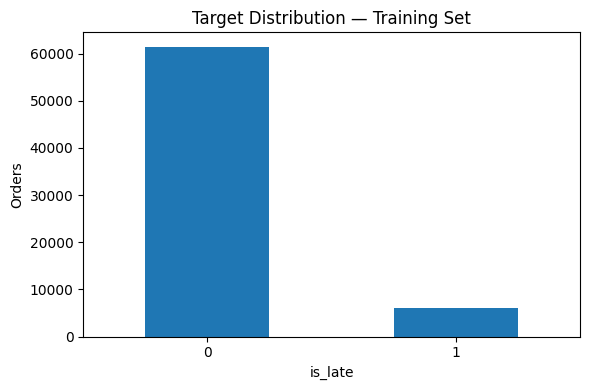

In [7]:
# ================================================================
# TARGET DISTRIBUTION
# ================================================================

fig, ax = plt.subplots(figsize=(6, 4))

target_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Target Distribution — Training Set")
ax.set_xlabel(TARGET)
ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    artifact_dir / "01_target_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [8]:

# ================================================================
# 6. PREDICTION-TIME LEAKAGE AUDIT
# ================================================================
# This audit is deliberately explicit. Pattern matching alone can miss
# derived variables such as delivery_delay_days, while a blanket "review"
# status is too vague for Notebook 5.
#
# Prediction point:
#   after order placement/payment information is available,
#   before carrier/delivery outcomes and customer reviews.

KNOWN_POST_OUTCOME = {
    "order_delivered_carrier_date":
        "Carrier delivery event occurs after the order is placed.",
    "order_delivered_customer_date":
        "Actual customer delivery date is the outcome used to define is_late.",
    "delivery_delay_days":
        "Derived directly from actual delivery versus estimated delivery.",
    "average_review_score":
        "Customer review information is only available after delivery.",
    "review_count":
        "Review information is only available after delivery.",
}

KNOWN_SAFE = {
    "order_purchase_timestamp":
        "Available when the order is placed.",
    "order_estimated_delivery_date":
        "The promised/estimated delivery date is known before delivery.",
    "customer_state":
        "Customer location is available with the order.",
    "customer_city":
        "Customer location is available with the order.",
    "customer_zip_code_prefix":
        "Customer location is available with the order.",
    "seller_state":
        "Seller location is available from the order/seller information.",
    "seller_city":
        "Seller location is available from the order/seller information.",
    "seller_zip_code_prefix":
        "Seller location is available from the order/seller information.",
    "item_count":
        "Order-level item count is known from the order contents.",
    "unique_products":
        "Product count is known from the order contents.",
    "unique_sellers":
        "Seller count is known from the order contents.",
    "total_item_value":
        "Order value is known from the order contents.",
    "total_freight_value":
        "Freight value is known from the order/payment information.",
    "payment_count":
        "Payment count is known from the order/payment information.",
    "total_payment_value":
        "Payment value is known from the order/payment information.",
    "max_payment_installments":
        "Payment installment information is available with the order.",
    "distance_km":
        "Distance is a pre-outcome geographic feature if calculated only from locations.",
}

KNOWN_REVIEW = {
    "order_status":
        "Status can change after order placement; do not use unless the exact prediction timestamp is defined.",
    "order_approved_at":
        "Available shortly after purchase, but safe only if prediction occurs after approval.",
    "order_id":
        "Identifier; not a predictive feature.",
    "customer_id":
        "Identifier; not a predictive feature.",
    "customer_unique_id":
        "Identifier; not a predictive feature.",
}

prediction_time_audit_rows = []

for col in train_df.columns:
    if col == TARGET:
        status = "TARGET"
        reason = "Prediction target; never use as an input feature."
    elif col in KNOWN_POST_OUTCOME:
        status = "POTENTIAL_LEAKAGE"
        reason = KNOWN_POST_OUTCOME[col]
    elif col in KNOWN_SAFE:
        status = "LIKELY_SAFE"
        reason = KNOWN_SAFE[col]
    elif col in KNOWN_REVIEW:
        status = "REVIEW"
        reason = KNOWN_REVIEW[col]
    else:
        status = "REVIEW"
        reason = "Prediction-time availability must be confirmed."

    prediction_time_audit_rows.append({
        "column": col,
        "prediction_time_status": status,
        "reason": reason,
    })

prediction_time_audit = pd.DataFrame(prediction_time_audit_rows)

display(prediction_time_audit)

prediction_time_audit.to_csv(
    artifact_dir / "prediction_time_audit.csv",
    index=False
)

# Explicit sets used by the downstream EDA sections.
LEAKAGE_COLUMNS = [
    c for c in train_df.columns
    if c in KNOWN_POST_OUTCOME
]

SAFE_FEATURE_COLUMNS = [
    c for c in train_df.columns
    if c in KNOWN_SAFE
]

REVIEW_COLUMNS = [
    c for c in train_df.columns
    if c in KNOWN_REVIEW
]

print("\nPrediction-time summary:")
print(f"  Safe candidates       : {len(SAFE_FEATURE_COLUMNS)}")
print(f"  Potential leakage     : {len(LEAKAGE_COLUMNS)}")
print(f"  Requires review       : {len(REVIEW_COLUMNS)}")


,column,prediction_time_status,reason
0,order_id,REVIEW,Identifier; not a predictive feature.
1,customer_id,REVIEW,Identifier; not a predictive feature.
2,order_status,REVIEW,Status can change after order placement; do no...
3,order_purchase_timestamp,LIKELY_SAFE,Available when the order is placed.
4,order_approved_at,REVIEW,"Available shortly after purchase, but safe onl..."
5,order_delivered_carrier_date,POTENTIAL_LEAKAGE,Carrier delivery event occurs after the order ...
6,order_delivered_customer_date,POTENTIAL_LEAKAGE,Actual customer delivery date is the outcome u...
7,order_estimated_delivery_date,LIKELY_SAFE,The promised/estimated delivery date is known ...
8,customer_unique_id,REVIEW,Identifier; not a predictive feature.
9,customer_zip_code_prefix,LIKELY_SAFE,Customer location is available with the order.



Prediction-time summary:
  Safe candidates       : 17
  Potential leakage     : 5
  Requires review       : 5


,missing_count,missing_pct
average_review_score,515,0.76
review_count,515,0.76
distance_km,344,0.51
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
max_payment_installments,1,0.00
total_payment_value,1,0.00
payment_count,1,0.00


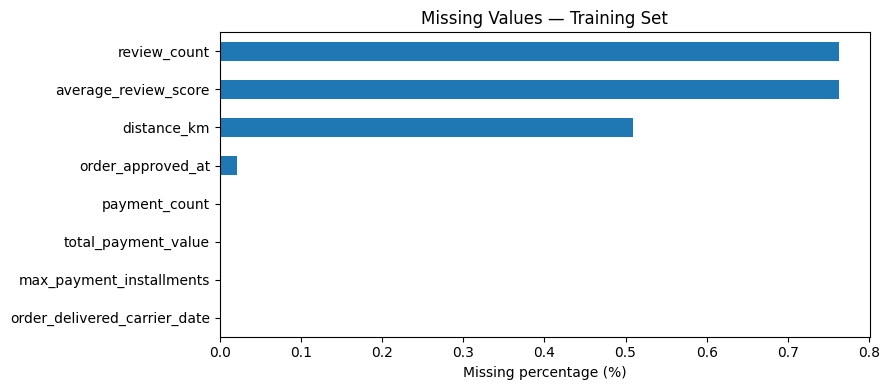

In [9]:
# ================================================================
# 7. MISSING-VALUE ANALYSIS
# ================================================================

missing = (
    train_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

if missing.empty:

    print("No missing values found in the training split.")

else:

    missing_summary = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": (
            missing / len(train_df) * 100
        ),
    })

    display(missing_summary.round(2))

    fig, ax = plt.subplots(
        figsize=(9, max(4, len(missing) * 0.3))
    )

    (
        missing_summary["missing_pct"]
        .sort_values()
        .plot(
            kind="barh",
            ax=ax
        )
    )

    ax.set_title(
        "Missing Values — Training Set"
    )

    ax.set_xlabel(
        "Missing percentage (%)"
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir / "02_missing_values.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [10]:
# ================================================================
# MISSINGNESS × TARGET
# ================================================================

missing_rows = []

for col in train_df.columns:

    missing_flag = train_df[col].isna()

    if missing_flag.sum() == 0:
        continue

    present_rate = train_df.loc[
        ~missing_flag,
        TARGET
    ].mean()

    missing_rate = train_df.loc[
        missing_flag,
        TARGET
    ].mean()

    missing_rows.append({
        "column": col,
        "missing_count": int(
            missing_flag.sum()
        ),
        "missing_pct": (
            missing_flag.mean() * 100
        ),
        "late_rate_missing": (
            missing_rate * 100
        ),
        "late_rate_present": (
            present_rate * 100
        ),
        "late_rate_difference_pp": (
            (missing_rate - present_rate)
            * 100
        ),
    })


if missing_rows:

    missing_target = (
        pd.DataFrame(missing_rows)
        .sort_values(
            "late_rate_difference_pp",
            key=lambda x: x.abs(),
            ascending=False
        )
    )

    display(
        missing_target.round(2)
    )

    missing_target.to_csv(
        artifact_dir
        / "missingness_target_analysis.csv",
        index=False
    )

else:

    missing_target = pd.DataFrame()

    print(
        "No columns contain missing values."
    )

,column,missing_count,missing_pct,late_rate_missing,late_rate_present,late_rate_difference_pp
1,order_delivered_carrier_date,1,0.00,100.00,9.02,90.98
2,payment_count,1,0.00,100.00,9.02,90.98
3,total_payment_value,1,0.00,100.00,9.02,90.98
4,max_payment_installments,1,0.00,100.00,9.02,90.98
5,review_count,515,0.76,26.60,8.89,17.71
6,average_review_score,515,0.76,26.60,8.89,17.71
0,order_approved_at,14,0.02,0.00,9.03,-9.03
7,distance_km,344,0.51,11.05,9.01,2.03


In [11]:

# ================================================================
# 8. NUMERICAL FEATURES
# ================================================================
# For feature-oriented EDA, exclude variables known to be generated
# after the outcome. We keep them in the leakage audit and delivery
# diagnostics so the notebook can demonstrate why they must not be used.

numeric_cols = [
    c
    for c in train_df.select_dtypes(include=np.number).columns
    if c != TARGET and c not in LEAKAGE_COLUMNS
]

print(f"Prediction-time-safe numerical candidates: {len(numeric_cols)}")
print(numeric_cols)


Prediction-time-safe numerical candidates: 11
['customer_zip_code_prefix', 'item_count', 'unique_products', 'unique_sellers', 'total_item_value', 'total_freight_value', 'payment_count', 'total_payment_value', 'max_payment_installments', 'seller_zip_code_prefix', 'distance_km']


In [12]:
# ================================================================
# NUMERICAL SUMMARY
# ================================================================

numeric_rows = []

for col in numeric_cols:

    s = train_df[col].dropna()

    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (s < lower) |
        (s > upper)
    )

    numeric_rows.append({
        "column": col,
        "count": len(s),
        "missing_pct": (
            train_df[col].isna().mean() * 100
        ),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "p05": s.quantile(0.05),
        "p25": q1,
        "median": s.median(),
        "p75": q3,
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "skew": s.skew(),
        "iqr_lower": lower,
        "iqr_upper": upper,
        "outlier_count_iqr": int(
            outliers.sum()
        ),
        "outlier_pct_iqr": (
            outliers.mean() * 100
        ),
        "zero_count": int(
            (s == 0).sum()
        ),
        "zero_pct": (
            (s == 0).mean() * 100
        ),
        "negative_count": int(
            (s < 0).sum()
        ),
    })


numerical_summary = pd.DataFrame(
    numeric_rows
)

display(
    numerical_summary.round(3)
)

numerical_summary.to_csv(
    artifact_dir / "numerical_summary.csv",
    index=False
)

,column,count,missing_pct,mean,std,min,p01,p05,p25,median,...,p99,max,skew,iqr_lower,iqr_upper,outlier_count_iqr,outlier_pct_iqr,zero_count,zero_pct,negative_count
0,customer_zip_code_prefix,67533,0.000,36010.132,29908.267,1004.00,1408.000,3430.80,12061.00,25959.00,...,97572.680,99980.00,0.740,-60387.500,132808.500,0,0.000,0,0.000,0
1,item_count,67533,0.000,1.142,0.542,1.00,1.000,1.00,1.00,1.00,...,3.000,21.00,8.107,1.000,1.000,6759,10.008,0,0.000,0
2,unique_products,67533,0.000,1.038,0.222,1.00,1.000,1.00,1.00,1.00,...,2.000,7.00,7.675,1.000,1.000,2210,3.272,0,0.000,0
3,unique_sellers,67533,0.000,1.012,0.115,1.00,1.000,1.00,1.00,1.00,...,2.000,5.00,10.525,1.000,1.000,776,1.149,0,0.000,0
4,total_item_value,67533,0.000,135.884,205.188,2.29,11.990,19.00,45.90,85.00,...,987.000,13440.00,10.719,-110.100,305.900,5361,7.938,0,0.000,0
5,total_freight_value,67533,0.000,22.244,20.000,0.00,7.780,8.37,14.10,16.79,...,98.144,1002.29,8.584,-0.300,38.100,6629,9.816,10,0.015,0
6,payment_count,67532,0.001,1.048,0.397,1.00,1.000,1.00,1.00,1.00,...,2.000,26.00,22.420,1.000,1.000,2129,3.153,0,0.000,0
7,total_payment_value,67532,0.001,158.168,214.278,10.07,22.950,32.38,61.63,104.19,...,1039.850,13664.08,10.150,-109.152,346.267,5308,7.860,0,0.000,0
8,max_payment_installments,67532,0.001,2.974,2.755,1.00,1.000,1.00,1.00,2.00,...,10.000,24.00,1.593,-3.500,8.500,4677,6.926,0,0.000,0
9,seller_zip_code_prefix,67533,0.000,24827.631,27825.609,1001.00,1212.000,2972.00,6544.00,13912.00,...,92030.000,99730.00,1.523,-28910.000,65634.000,10507,15.558,0,0.000,0


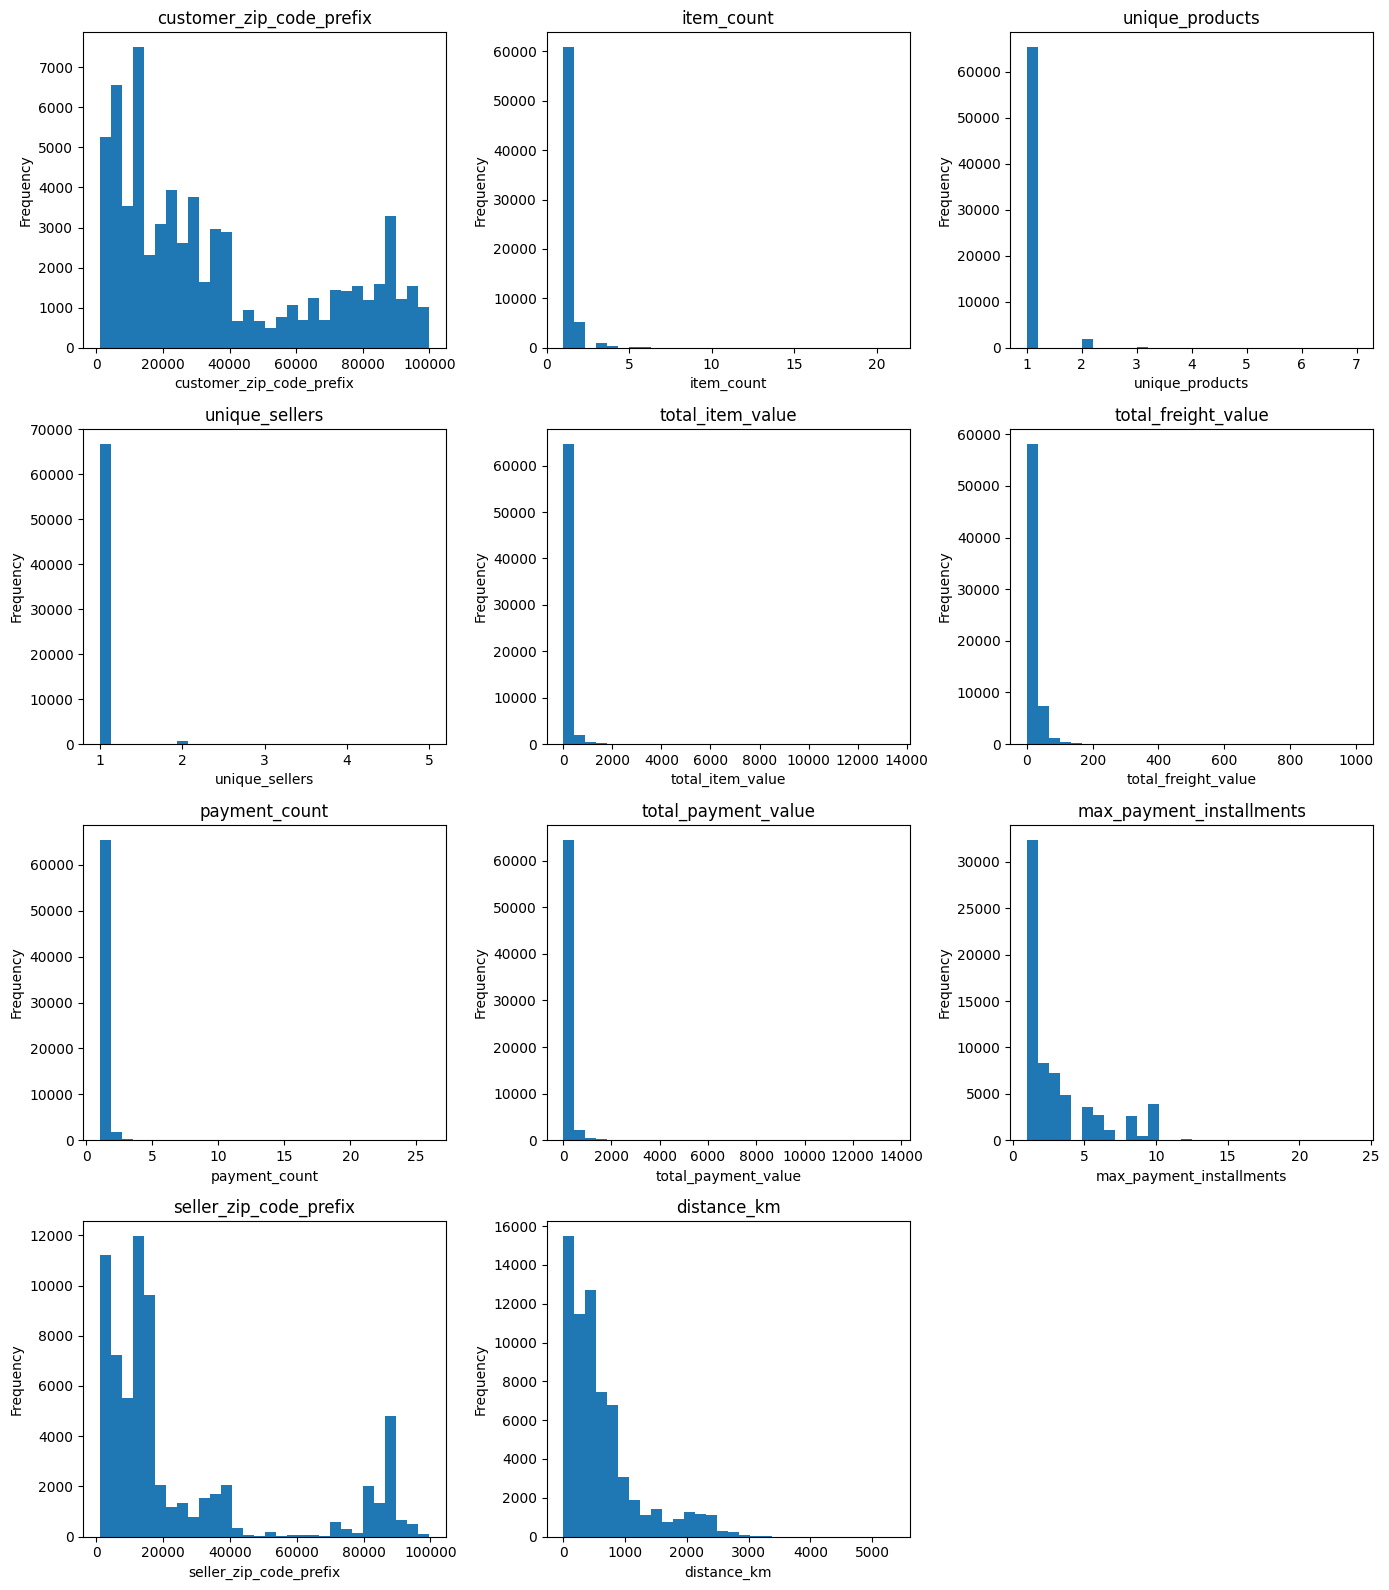

In [13]:
# ================================================================
# NUMERICAL DISTRIBUTIONS
# ================================================================

plot_features = [
    c
    for c in numeric_cols
    if train_df[c].nunique(
        dropna=True
    ) > 1
][:12]

if plot_features:

    ncols = 3
    nrows = int(
        np.ceil(
            len(plot_features) / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(14, 4 * nrows)
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, col in zip(
        axes,
        plot_features
    ):

        train_df[col].dropna().plot(
            kind="hist",
            bins=30,
            ax=ax
        )

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    for ax in axes[
        len(plot_features):
    ]:
        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "03_numerical_distributions.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [14]:
# ================================================================
# NUMERICAL RANGE SANITY CHECKS
# ================================================================

range_checks = []

for col in numeric_cols:

    name = col.lower()
    s = train_df[col]

    if any(
        token in name
        for token in [
            "distance",
            "duration",
            "days",
            "hours",
            "minutes",
        ]
    ):

        range_checks.append({
            "column": col,
            "check": "negative value",
            "count": int(
                (s < 0).sum()
            ),
        })

    if (
        "zip" in name
        or "postal" in name
    ):

        range_checks.append({
            "column": col,
            "check": "negative ZIP/prefix",
            "count": int(
                (s < 0).sum()
            ),
        })


range_checks = pd.DataFrame(
    range_checks
)

if not range_checks.empty:
    display(range_checks)
else:
    print(
        "No semantic numeric range checks "
        "were applicable."
    )

,column,check,count
0,customer_zip_code_prefix,negative ZIP/prefix,0
1,seller_zip_code_prefix,negative ZIP/prefix,0
2,distance_km,negative value,0


In [15]:
# ================================================================
# 10. CONSTANT FEATURES
# ================================================================

constant_rows = []

for col in train_df.columns:

    nunique = train_df[col].nunique(
        dropna=False
    )

    if nunique <= 1:

        constant_rows.append({
            "column": col,
            "unique_values": nunique,
        })


constant_features = pd.DataFrame(
    constant_rows
)

print("Constant features:")

if constant_features.empty:
    print("None detected.")
else:
    display(constant_features)

constant_features.to_csv(
    artifact_dir / "constant_features.csv",
    index=False
)

Constant features:
None detected.


In [16]:
# ================================================================
# NEAR-CONSTANT FEATURES
# ================================================================

near_constant_rows = []

for col in train_df.columns:

    value_pct = (
        train_df[col]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .iloc[0]
    )

    if value_pct >= 0.995:

        near_constant_rows.append({
            "column": col,
            "dominant_value_pct": (
                value_pct * 100
            ),
        })


near_constant = pd.DataFrame(
    near_constant_rows
).sort_values(
    "dominant_value_pct",
    ascending=False
)

print("Near-constant features:")

if near_constant.empty:
    print("None detected.")
else:
    display(
        near_constant.round(2)
    )

near_constant.to_csv(
    artifact_dir
    / "near_constant_features.csv",
    index=False
)

Near-constant features:


,column,dominant_value_pct
0,order_status,99.99


In [17]:

# ================================================================
# 11. CATEGORICAL FEATURES
# ================================================================

categorical_cols = [
    c
    for c in train_df.columns
    if classify_column(c, train_df[c]) == "Categorical"
    and c not in LEAKAGE_COLUMNS
]

print(
    f"Prediction-time-safe categorical candidates: "
    f"{len(categorical_cols)}"
)
print(categorical_cols)


Prediction-time-safe categorical candidates: 5
['order_status', 'customer_city', 'customer_state', 'seller_city', 'seller_state']


In [18]:
# ================================================================
# CATEGORICAL SUMMARY
# ================================================================

categorical_rows = []

for col in categorical_cols:

    s = train_df[col]

    vc = s.value_counts(
        dropna=False
    )

    rare_mask = (
        vc / len(s) < 0.01
    )

    categorical_rows.append({
        "column": col,

        "unique_values": (
            s.nunique(dropna=True)
        ),

        "cardinality_pct": (
            s.nunique(dropna=True)
            / len(s) * 100
        ),

        "missing_pct": (
            s.isna().mean() * 100
        ),

        "rare_categories": int(
            rare_mask.sum()
        ),

        "rows_in_rare_categories": int(
            vc[rare_mask].sum()
        ),

        "rare_rows_pct": (
            vc[rare_mask].sum()
            / len(s) * 100
        ),

        "top_category": (
            vc.index[0]
            if len(vc)
            else np.nan
        ),

        "top_category_pct": (
            vc.iloc[0] / len(s) * 100
            if len(vc)
            else np.nan
        ),
    })


categorical_summary = (
    pd.DataFrame(categorical_rows)
    .sort_values(
        "unique_values",
        ascending=False
    )
)

display(
    categorical_summary.round(2)
)

categorical_summary.to_csv(
    artifact_dir
    / "categorical_summary.csv",
    index=False
)

,column,unique_values,cardinality_pct,missing_pct,rare_categories,rows_in_rare_categories,rare_rows_pct,top_category,top_category_pct
1,customer_city,3747,5.55,0.0,3738,45059,66.72,sao paulo,14.69
3,seller_city,490,0.73,0.0,473,27904,41.32,sao paulo,24.36
2,customer_state,27,0.04,0.0,14,3934,5.83,SP,40.28
4,seller_state,22,0.03,0.0,16,2121,3.14,SP,70.85
0,order_status,2,0.00,0.0,1,6,0.01,delivered,99.99


In [19]:
# ================================================================
# CATEGORICAL VALUE COUNTS
# ================================================================

for col in categorical_cols:

    if train_df[col].nunique(
        dropna=True
    ) <= 30:

        print(f"\nValue counts: {col}")

        display(
            train_df[col]
            .value_counts(
                dropna=False
            )
            .head(30)
            .to_frame("count")
        )


Value counts: order_status


,count
order_status,
delivered,67527
canceled,6



Value counts: customer_state


,count
customer_state,
SP,27204
RJ,8967
MG,8130
RS,3912
PR,3461
SC,2577
BA,2307
ES,1445
GO,1409



Value counts: seller_state


,count
seller_state,
SP,47844
MG,5639
PR,5370
RJ,2693
SC,2583
RS,1283
DF,587
BA,407
GO,299


In [20]:
# ================================================================
# MESSY CATEGORY DETECTION
# ================================================================

messy_rows = []

for col in categorical_cols:

    s = train_df[col].dropna().astype(str)

    if s.empty:
        continue

    normalized = (
        s.str.strip()
        .str.lower()
    )

    raw_unique = s.nunique()
    normalized_unique = normalized.nunique()

    if raw_unique > normalized_unique:

        messy_rows.append({
            "column": col,
            "raw_unique": raw_unique,
            "normalized_unique": normalized_unique,
            "potential_duplicate_values": (
                raw_unique - normalized_unique
            ),
        })


messy_categories = pd.DataFrame(
    messy_rows
)

if messy_categories.empty:

    print(
        "No obvious case/whitespace "
        "duplicate patterns detected."
    )

else:

    display(messy_categories)

No obvious case/whitespace duplicate patterns detected.


In [21]:
# ================================================================
# 12. DATE/TIME DETECTION
# ================================================================

date_cols = []

for col in train_df.columns:

    name = col.lower()

    if (
        pd.api.types.is_datetime64_any_dtype(
            train_df[col]
        )
        or any(
            token in name
            for token in [
                "date",
                "timestamp",
                "datetime",
                "_at",
            ]
        )
    ):

        date_cols.append(col)


print(
    f"Date/time columns detected: "
    f"{len(date_cols)}"
)

print(date_cols)

Date/time columns detected: 5
['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [22]:
# ================================================================
# EDA DATE DATAFRAME
# ================================================================

date_df = pd.DataFrame(
    index=train_df.index
)

for col in date_cols:

    parsed = pd.to_datetime(
        train_df[col],
        errors="coerce"
    )

    date_df[col] = parsed

    print(
        f"{col}: "
        f"{parsed.notna().sum():,} valid | "
        f"{parsed.isna().sum():,} missing/unparseable"
    )

order_purchase_timestamp: 67,533 valid | 0 missing/unparseable
order_approved_at: 67,519 valid | 14 missing/unparseable
order_delivered_carrier_date: 67,532 valid | 1 missing/unparseable
order_delivered_customer_date: 67,533 valid | 0 missing/unparseable
order_estimated_delivery_date: 67,533 valid | 0 missing/unparseable


In [23]:
# ================================================================
# ORDER TIMING
# ================================================================

ORDER_TIMESTAMP = "order_purchase_timestamp"

if ORDER_TIMESTAMP in train_df.columns:

    order_datetime = pd.to_datetime(
        train_df[ORDER_TIMESTAMP],
        errors="coerce"
    )

    date_df["order_datetime"] = (
        order_datetime
    )

    date_df["order_year"] = (
        order_datetime.dt.year
    )

    date_df["order_month"] = (
        order_datetime.dt.month
    )

    date_df["order_day"] = (
        order_datetime.dt.day
    )

    date_df["order_hour"] = (
        order_datetime.dt.hour
    )

    date_df["order_dayofweek"] = (
        order_datetime.dt.dayofweek
    )

    date_df["is_weekend"] = (
        order_datetime.dt.dayofweek >= 5
    ).astype("Int64")

    date_df[TARGET] = (
        train_df[TARGET].values
    )

    print("Order timing variables created for EDA.")

    display(
        date_df.head()
    )

else:

    print(
        f"{ORDER_TIMESTAMP} was not found."
    )

Order timing variables created for EDA.


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_datetime,order_year,order_month,order_day,order_hour,order_dayofweek,is_weekend,is_late
0,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,2016-09-15 12:16:38,2016,9,15,12,3,0,1
1,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,2016-10-03 09:44:50,2016,10,3,9,0,0,0
2,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2016-10-03 16:56:50,2016,10,3,16,0,0,0
3,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,2016-10-03 21:01:41,2016,10,3,21,0,0,0
4,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,2016-10-03 21:13:36,2016,10,3,21,0,0,0


,month,orders,late_rate,late_rate_pct
0,2016-09,1,1.00,100.00
1,2016-10,270,0.01,1.11
2,2016-12,1,0.00,0.00
3,2017-01,750,0.03,3.07
4,2017-02,1653,0.03,3.21
5,2017-03,2546,0.06,5.58
6,2017-04,2303,0.08,7.86
7,2017-05,3545,0.04,3.61
8,2017-06,3135,0.04,3.86
9,2017-07,3872,0.03,3.43


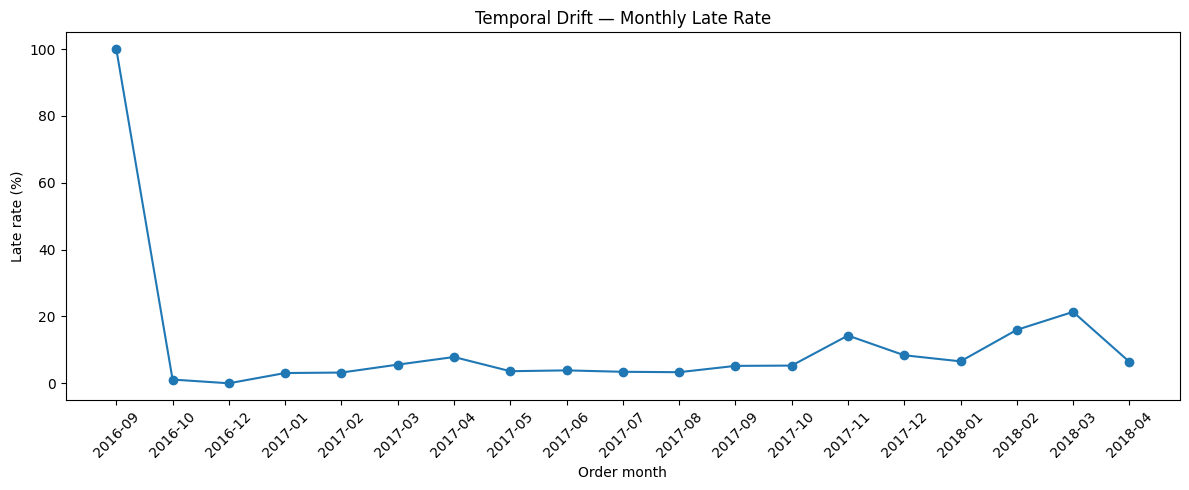

In [24]:
# ================================================================
# 14. TEMPORAL DRIFT — MONTHLY LATE RATE
# ================================================================

if "order_datetime" in date_df.columns:

    monthly_drift = (
        date_df
        .dropna(
            subset=["order_datetime"]
        )
        .assign(
            month=lambda x:
                x["order_datetime"].dt.to_period("M")
        )
        .groupby("month")[TARGET]
        .agg(
            orders="size",
            late_rate="mean"
        )
        .reset_index()
    )

    monthly_drift["late_rate_pct"] = (
        monthly_drift["late_rate"] * 100
    )

    display(
        monthly_drift.round(2)
    )

    monthly_drift.to_csv(
        artifact_dir
        / "temporal_late_rate.csv",
        index=False
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    ax.plot(
        monthly_drift["month"].astype(str),
        monthly_drift["late_rate_pct"],
        marker="o"
    )

    ax.set_title(
        "Temporal Drift — Monthly Late Rate"
    )

    ax.set_xlabel(
        "Order month"
    )

    ax.set_ylabel(
        "Late rate (%)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "08_temporal_late_rate.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:

    monthly_drift = pd.DataFrame()

    print(
        "Order datetime unavailable; "
        "temporal drift analysis skipped."
    )

,weekday,weekday_name,orders,late_rate_pct
0,0,Monday,10736,10.02
1,1,Tuesday,10729,9.26
2,2,Wednesday,10339,8.60
3,3,Thursday,10005,8.28
4,4,Friday,9885,9.47
5,5,Saturday,7594,8.97
6,6,Sunday,8245,8.38


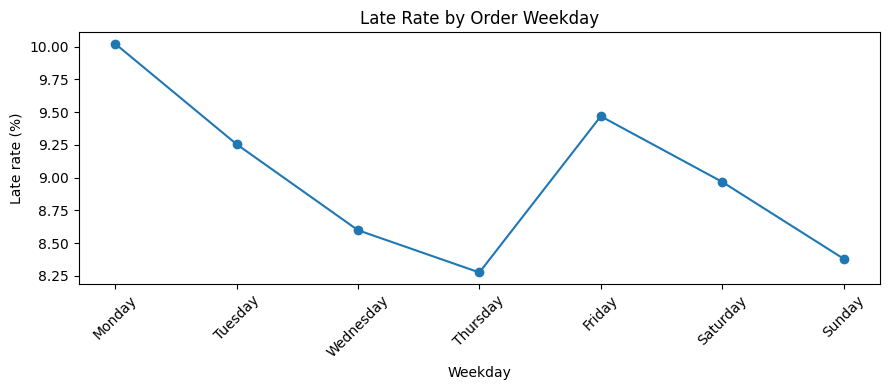

In [25]:
# ================================================================
# 15. WEEKDAY ANALYSIS
# ================================================================

if "order_datetime" in date_df.columns:

    weekday_analysis = (
        date_df
        .dropna(
            subset=["order_datetime"]
        )
        .assign(
            weekday=lambda x:
                x["order_datetime"].dt.dayofweek
        )
        .groupby("weekday")[TARGET]
        .agg(
            orders="size",
            late_rate="mean"
        )
        .reset_index()
    )

    weekday_analysis["weekday_name"] = (
        weekday_analysis["weekday"]
        .map(
            dict(
                enumerate(
                    calendar.day_name
                )
            )
        )
    )

    weekday_analysis["late_rate_pct"] = (
        weekday_analysis["late_rate"] * 100
    )

    weekday_analysis = (
        weekday_analysis[
            [
                "weekday",
                "weekday_name",
                "orders",
                "late_rate_pct",
            ]
        ]
    )

    display(
        weekday_analysis.round(2)
    )

    weekday_analysis.to_csv(
        artifact_dir
        / "weekday_late_rate.csv",
        index=False
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    ax.plot(
        weekday_analysis["weekday_name"],
        weekday_analysis["late_rate_pct"],
        marker="o"
    )

    ax.set_title(
        "Late Rate by Order Weekday"
    )

    ax.set_xlabel(
        "Weekday"
    )

    ax.set_ylabel(
        "Late rate (%)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "05_weekday_late_rate.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:

    weekday_analysis = pd.DataFrame()

    print(
        "Order datetime unavailable."
    )

,hour,orders,late_rate,late_rate_pct
0,0,1662,0.10,9.69
1,1,837,0.09,8.84
2,2,370,0.08,7.84
3,3,186,0.05,4.84
4,4,136,0.07,7.35
5,5,134,0.08,8.21
6,6,318,0.08,8.18
7,7,806,0.08,8.06
8,8,1951,0.09,8.51
9,9,3211,0.09,8.56


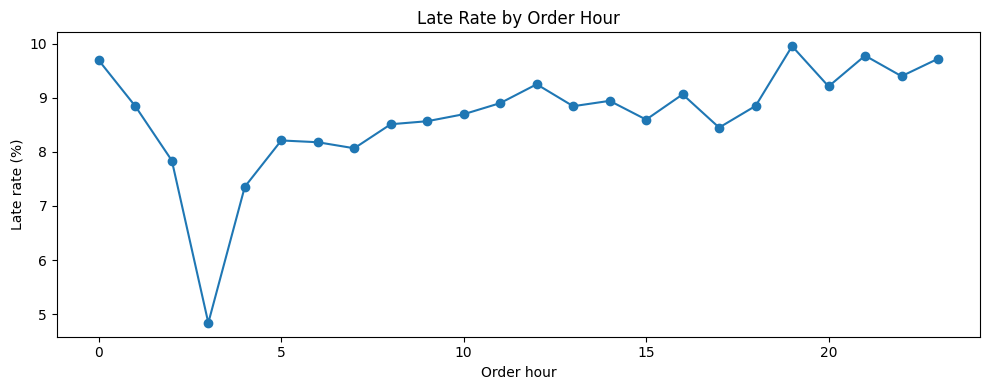

In [26]:
# ================================================================
# 16. HOUR-OF-DAY ANALYSIS
# ================================================================

if "order_datetime" in date_df.columns:

    hourly_analysis = (
        date_df
        .dropna(
            subset=["order_datetime"]
        )
        .assign(
            hour=lambda x:
                x["order_datetime"].dt.hour
        )
        .groupby("hour")[TARGET]
        .agg(
            orders="size",
            late_rate="mean"
        )
        .reset_index()
    )

    hourly_analysis["late_rate_pct"] = (
        hourly_analysis["late_rate"] * 100
    )

    display(
        hourly_analysis.round(2)
    )

    hourly_analysis.to_csv(
        artifact_dir
        / "hourly_late_rate.csv",
        index=False
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.plot(
        hourly_analysis["hour"],
        hourly_analysis["late_rate_pct"],
        marker="o"
    )

    ax.set_title(
        "Late Rate by Order Hour"
    )

    ax.set_xlabel(
        "Order hour"
    )

    ax.set_ylabel(
        "Late rate (%)"
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "09_hourly_late_rate.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:

    hourly_analysis = pd.DataFrame()

    print(
        "Order datetime unavailable."
    )

,month,orders,late_rate,month_name,late_rate_pct
0,1,7819,0.06,January,6.23
1,2,8209,0.13,February,13.41
2,3,9549,0.17,March,17.15
3,4,5510,0.07,April,7.02
4,5,3545,0.04,May,3.61
5,6,3135,0.04,June,3.86
6,7,3872,0.03,July,3.43
7,8,4193,0.03,August,3.32
8,9,4151,0.05,September,5.23
9,10,4748,0.05,October,5.05


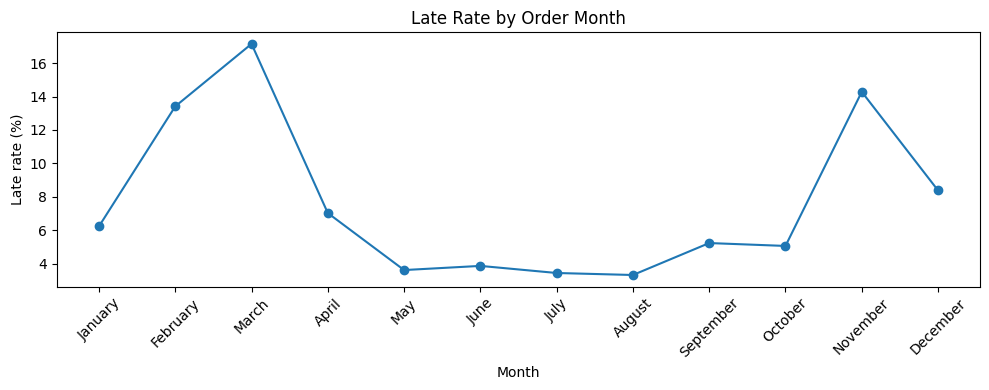

In [27]:
# ================================================================
# 17. MONTHLY SEASONALITY
# ================================================================

if "order_datetime" in date_df.columns:

    month_analysis = (
        date_df
        .dropna(
            subset=["order_datetime"]
        )
        .assign(
            month=lambda x:
                x["order_datetime"].dt.month
        )
        .groupby("month")[TARGET]
        .agg(
            orders="size",
            late_rate="mean"
        )
        .reset_index()
    )

    month_analysis["month_name"] = (
        month_analysis["month"]
        .map(
            dict(
                enumerate(
                    calendar.month_name
                )
            )
        )
    )

    month_analysis["late_rate_pct"] = (
        month_analysis["late_rate"] * 100
    )

    display(
        month_analysis.round(2)
    )

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.plot(
        month_analysis["month_name"],
        month_analysis["late_rate_pct"],
        marker="o"
    )

    ax.set_title(
        "Late Rate by Order Month"
    )

    ax.set_xlabel(
        "Month"
    )

    ax.set_ylabel(
        "Late rate (%)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "06_monthly_late_rate.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

,is_holiday,orders,late_rate,late_rate_pct
0,False,65834,0.09,9.03
1,True,1699,0.09,8.71


,holiday_name,orders,late_rate,late_rate_pct
1,Carnival Monday,255,0.15,15.29
5,Good Friday,210,0.12,11.90
2,Carnival Tuesday,270,0.11,11.11
3,Christmas,86,0.08,8.14
11,Tiradentes,66,0.08,7.58
10,Republic Day,176,0.07,7.39
8,New Year,72,0.06,5.56
0,All Souls Day,117,0.05,5.13
4,Corpus Christi,103,0.05,4.85
7,Labor Day,111,0.05,4.50


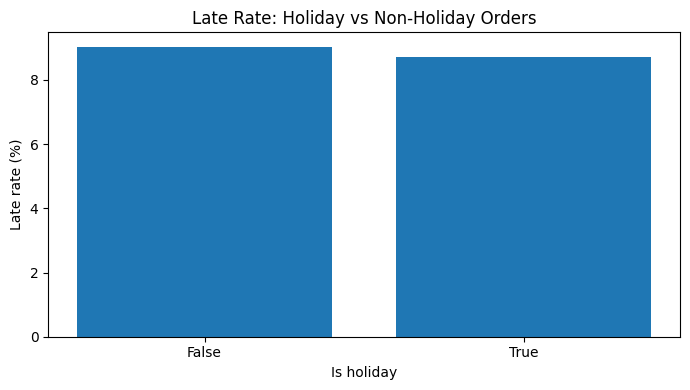

In [28]:

# ================================================================
# 17B. HOLIDAY EFFECTS
# ================================================================
# Olist covers orders from 2016–2018. We compare order-level late
# rates on selected Brazilian national / widely observed public
# holidays versus non-holiday dates.
#
# Holiday dates are based on Brazilian federal/public holiday
# calendars for the dataset years. Carnival and Corpus Christi are
# included as widely observed movable holidays because they can affect
# logistics even when classified as optional in some federal calendars.

BRAZIL_HOLIDAYS = {
    # 2016
    "2016-01-01": "New Year",
    "2016-02-08": "Carnival Monday",
    "2016-02-09": "Carnival Tuesday",
    "2016-03-25": "Good Friday",
    "2016-04-21": "Tiradentes",
    "2016-05-01": "Labor Day",
    "2016-05-26": "Corpus Christi",
    "2016-09-07": "Independence Day",
    "2016-10-12": "Our Lady of Aparecida",
    "2016-11-02": "All Souls Day",
    "2016-11-15": "Republic Day",
    "2016-12-25": "Christmas",

    # 2017
    "2017-01-01": "New Year",
    "2017-02-27": "Carnival Monday",
    "2017-02-28": "Carnival Tuesday",
    "2017-04-14": "Good Friday",
    "2017-04-21": "Tiradentes",
    "2017-05-01": "Labor Day",
    "2017-06-15": "Corpus Christi",
    "2017-09-07": "Independence Day",
    "2017-10-12": "Our Lady of Aparecida",
    "2017-11-02": "All Souls Day",
    "2017-11-15": "Republic Day",
    "2017-12-25": "Christmas",

    # 2018
    "2018-01-01": "New Year",
    "2018-02-12": "Carnival Monday",
    "2018-02-13": "Carnival Tuesday",
    "2018-03-30": "Good Friday",
    "2018-04-21": "Tiradentes",
    "2018-05-01": "Labor Day",
    "2018-05-31": "Corpus Christi",
    "2018-09-07": "Independence Day",
    "2018-10-12": "Our Lady of Aparecida",
    "2018-11-02": "All Souls Day",
    "2018-11-15": "Republic Day",
    "2018-12-25": "Christmas",
}

if "order_datetime" in date_df.columns:
    holiday_map = pd.Series(BRAZIL_HOLIDAYS)
    holiday_map.index = pd.to_datetime(holiday_map.index)

    date_df["holiday_name"] = (
        date_df["order_datetime"].dt.normalize().map(holiday_map)
    )
    date_df["is_holiday"] = date_df["holiday_name"].notna()

    holiday_analysis = (
        date_df
        .groupby("is_holiday")[TARGET]
        .agg(orders="size", late_rate="mean")
        .reset_index()
    )
    holiday_analysis["late_rate_pct"] = (
        holiday_analysis["late_rate"] * 100
    )

    display(holiday_analysis.round(2))

    holiday_detail = (
        date_df[date_df["is_holiday"]]
        .groupby("holiday_name")[TARGET]
        .agg(orders="size", late_rate="mean")
        .reset_index()
        .sort_values("late_rate", ascending=False)
    )
    holiday_detail["late_rate_pct"] = (
        holiday_detail["late_rate"] * 100
    )

    display(holiday_detail.round(2))

    holiday_analysis.to_csv(
        artifact_dir / "holiday_late_rate.csv",
        index=False
    )
    holiday_detail.to_csv(
        artifact_dir / "holiday_detail_late_rate.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(
        holiday_analysis["is_holiday"].astype(str),
        holiday_analysis["late_rate_pct"]
    )
    ax.set_title("Late Rate: Holiday vs Non-Holiday Orders")
    ax.set_xlabel("Is holiday")
    ax.set_ylabel("Late rate (%)")
    plt.tight_layout()
    plt.savefig(
        artifact_dir / "10_holiday_late_rate.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
else:
    holiday_analysis = pd.DataFrame()
    holiday_detail = pd.DataFrame()
    print("Order datetime unavailable; holiday analysis skipped.")


In [29]:
# ================================================================
# 18. DELIVERY-TIME ANALYSIS
# ================================================================

actual_delivery_col = next(
    (
        c for c in date_cols
        if (
            "delivered_customer" in c.lower()
            or (
                "delivery" in c.lower()
                and "actual" in c.lower()
            )
        )
    ),
    None
)

estimated_delivery_col = next(
    (
        c for c in date_cols
        if (
            "estimated" in c.lower()
            and "delivery" in c.lower()
        )
    ),
    None
)

print(
    "Actual delivery column   :",
    actual_delivery_col
)

print(
    "Estimated delivery column:",
    estimated_delivery_col
)

Actual delivery column   : order_delivered_customer_date
Estimated delivery column: order_estimated_delivery_date


,delivery_delay_days
count,67533.00
mean,-10.77
std,10.49
min,-146.02
1%,-34.31
25%,-15.97
50%,-11.94
75%,-7.01
95%,5.76
99%,21.86


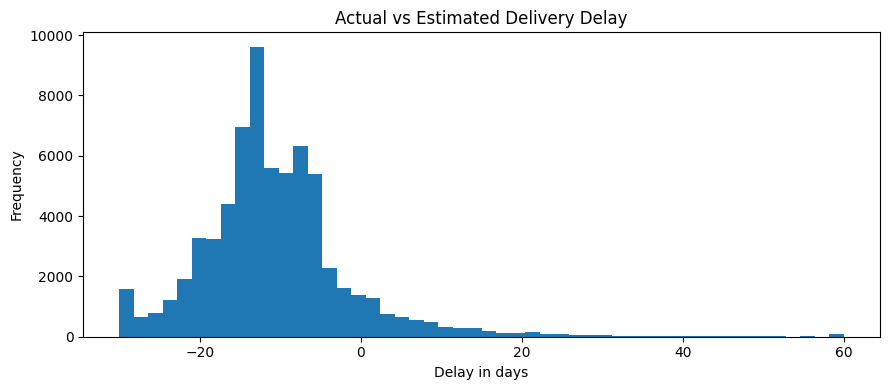

In [30]:
# ================================================================
# DELIVERY DELAY
# ================================================================

if (
    actual_delivery_col is not None
    and estimated_delivery_col is not None
):

    actual = date_df[
        actual_delivery_col
    ]

    estimated = date_df[
        estimated_delivery_col
    ]

    delivery_delay_days = (
        actual - estimated
    ).dt.total_seconds() / 86400

    delivery_delay_summary = (
        delivery_delay_days
        .describe(
            percentiles=[
                0.01,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
        .to_frame(
            "delivery_delay_days"
        )
    )

    display(
        delivery_delay_summary.round(2)
    )

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    (
        delivery_delay_days
        .dropna()
        .clip(-30, 60)
        .plot(
            kind="hist",
            bins=50,
            ax=ax
        )
    )

    ax.set_title(
        "Actual vs Estimated Delivery Delay"
    )

    ax.set_xlabel(
        "Delay in days"
    )

    ax.set_ylabel(
        "Frequency"
    )

    plt.tight_layout()

    plt.savefig(
        artifact_dir
        / "07_delivery_delay_distribution.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:

    delivery_delay_days = pd.Series(
        dtype="float64"
    )

    print(
        "Actual and estimated delivery "
        "dates were not both detected."
    )

In [31]:
# ================================================================
# 19. GEOGRAPHY
# ================================================================

geo_cols = [
    c
    for c in [
        "customer_state",
        "seller_state",
        "customer_zip_code_prefix",
        "seller_zip_code_prefix",
    ]
    if c in train_df.columns
]

print(
    "Detected geographic columns:"
)

print(geo_cols)

Detected geographic columns:
['customer_state', 'seller_state', 'customer_zip_code_prefix', 'seller_zip_code_prefix']


In [32]:
# ================================================================
# STATE × TARGET
# ================================================================

for col in [
    "customer_state",
    "seller_state",
]:

    if col not in train_df.columns:
        continue

    state_rate = (
        train_df
        .groupby(
            col,
            dropna=False
        )[TARGET]
        .agg(
            orders="size",
            late_rate="mean"
        )
        .sort_values(
            "late_rate",
            ascending=False
        )
    )

    state_rate["late_rate_pct"] = (
        state_rate["late_rate"] * 100
    )

    print(
        f"\nLate rate by {col}"
    )

    display(
        state_rate[
            [
                "orders",
                "late_rate_pct"
            ]
        ].round(2)
    )


Late rate by customer_state


,orders,late_rate_pct
customer_state,,
AL,298,27.85
MA,548,21.53
CE,948,18.25
RR,29,17.24
SE,246,17.07
PI,348,16.67
RJ,8967,16.58
BA,2307,15.00
PA,718,13.37



Late rate by seller_state


,orders,late_rate_pct
seller_state,,
AM,3,66.67
MA,63,38.10
CE,55,12.73
PA,8,12.50
RN,45,11.11
PB,19,10.53
RJ,2693,9.88
SP,47844,9.80
PR,5370,7.67


In [33]:
# ================================================================
# DISTANCE ANALYSIS
# ================================================================

distance_cols = [
    c
    for c in numeric_cols
    if "distance" in c.lower()
]

if distance_cols:

    for col in distance_cols:

        try:

            distance_bins = pd.qcut(
                train_df[col],
                q=10,
                duplicates="drop"
            )

            distance_rate = (
                train_df
                .groupby(
                    distance_bins,
                    observed=True
                )[TARGET]
                .agg(
                    orders="size",
                    late_rate="mean"
                )
            )

            distance_rate[
                "late_rate_pct"
            ] = (
                distance_rate["late_rate"]
                * 100
            )

            print(
                f"\nLate rate by distance "
                f"decile: {col}"
            )

            display(
                distance_rate.round(2)
            )

        except Exception as exc:

            print(
                f"Distance analysis failed "
                f"for {col}: {exc}"
            )

else:

    print(
        "No distance feature detected."
    )


Late rate by distance decile: distance_km


,orders,late_rate,late_rate_pct
distance_km,,,
"(-0.001, 40.22]",6720,0.05,4.51
"(40.22, 133.696]",6718,0.05,5.49
"(133.696, 293.284]",6719,0.07,6.97
"(293.284, 355.15]",6721,0.10,9.60
"(355.15, 448.56]",6717,0.09,8.95
"(448.56, 544.19]",6718,0.09,9.02
"(544.19, 709.942]",6719,0.11,10.98
"(709.942, 886.498]",6719,0.09,9.41
"(886.498, 1467.232]",6719,0.10,10.48


In [34]:
# ================================================================
# 20. NUMERICAL FEATURES × TARGET
# ================================================================

numeric_target_analysis = []

for col in numeric_cols:

    s = train_df[col]

    if s.nunique(
        dropna=True
    ) < 5:

        continue

    try:

        bins = pd.qcut(
            s,
            q=10,
            duplicates="drop"
        )

        grouped = (
            train_df
            .groupby(
                bins,
                observed=True
            )[TARGET]
            .agg(
                orders="size",
                late_rate="mean"
            )
            .reset_index()
        )

        grouped["feature"] = col

        grouped["late_rate_pct"] = (
            grouped["late_rate"] * 100
        )

        numeric_target_analysis.append(
            grouped
        )

    except Exception:
        continue


if numeric_target_analysis:

    numeric_target_analysis_df = pd.concat(
        numeric_target_analysis,
        ignore_index=True
    )

    display(
        numeric_target_analysis_df.head(30)
    )

    numeric_target_analysis_df.to_csv(
        artifact_dir
        / "numeric_target_bins.csv",
        index=False
    )

else:

    numeric_target_analysis_df = pd.DataFrame()

    print(
        "No numerical target-bin analysis "
        "could be generated."
    )

,customer_zip_code_prefix,orders,late_rate,feature,late_rate_pct,item_count,unique_products,unique_sellers,total_item_value,total_freight_value,payment_count,total_payment_value,max_payment_installments,seller_zip_code_prefix,distance_km
0,"(1003.999, 4844.0]",6769,0.048013,customer_zip_code_prefix,4.801300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(4844.0, 8790.0]",6739,0.057575,customer_zip_code_prefix,5.757531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(8790.0, 13280.0]",6759,0.070425,customer_zip_code_prefix,7.042462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(13280.0, 19696.0]",6746,0.048770,customer_zip_code_prefix,4.876964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(19696.0, 25959.0]",6755,0.152924,customer_zip_code_prefix,15.292376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"(25959.0, 35162.0]",6784,0.125000,customer_zip_code_prefix,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"(35162.0, 45652.0]",6724,0.082986,customer_zip_code_prefix,8.298632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"(45652.0, 71926.0]",6754,0.144507,customer_zip_code_prefix,14.450696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"(71926.0, 87111.0]",6751,0.074063,customer_zip_code_prefix,7.406310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,"(87111.0, 99980.0]",6752,0.097897,customer_zip_code_prefix,9.789692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,correlation_with_is_late
seller_zip_code_prefix,-0.0374
unique_sellers,-0.0259
unique_products,-0.0216
item_count,-0.0161
payment_count,-0.0059
max_payment_installments,0.0172
total_item_value,0.0213
total_payment_value,0.0247
customer_zip_code_prefix,0.0404
total_freight_value,0.0467


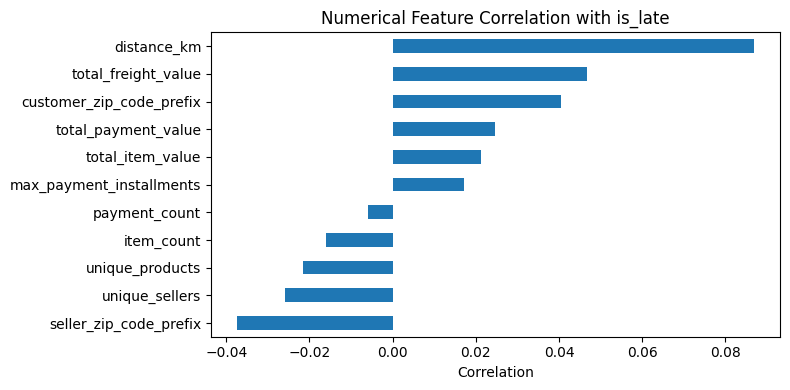

In [35]:
# ================================================================
# 21. NUMERICAL CORRELATIONS
# ================================================================

if numeric_cols:

    numeric_target_corr = (
        train_df[
            numeric_cols + [TARGET]
        ]
        .corr(numeric_only=True)[TARGET]
        .drop(TARGET)
        .sort_values()
    )

    display(
        numeric_target_corr.to_frame(
            "correlation_with_is_late"
        ).round(4)
    )

    if not numeric_target_corr.empty:

        fig, ax = plt.subplots(
            figsize=(
                8,
                max(
                    4,
                    len(numeric_target_corr)
                    * 0.3
                )
            )
        )

        numeric_target_corr.plot(
            kind="barh",
            ax=ax
        )

        ax.set_title(
            "Numerical Feature Correlation "
            "with is_late"
        )

        ax.set_xlabel(
            "Correlation"
        )

        plt.tight_layout()

        plt.savefig(
            artifact_dir
            / "04_numeric_target_correlations.png",
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

else:

    numeric_target_corr = pd.Series(
        dtype="float64"
    )

In [36]:
# ================================================================
# 22. CATEGORICAL FEATURES × TARGET
# ================================================================

categorical_target_tables = {}

for col in categorical_cols:

    if train_df[col].nunique(
        dropna=True
    ) <= 30:

        table = (
            train_df
            .groupby(
                col,
                dropna=False
            )[TARGET]
            .agg(
                orders="size",
                late_rate="mean"
            )
            .sort_values(
                "late_rate",
                ascending=False
            )
        )

        table["late_rate_pct"] = (
            table["late_rate"] * 100
        )

        categorical_target_tables[col] = table

        print(
            f"\nLate rate by {col}"
        )

        display(
            table[
                [
                    "orders",
                    "late_rate_pct"
                ]
            ].round(2)
        )


Late rate by order_status


,orders,late_rate_pct
order_status,,
canceled,6,16.67
delivered,67527,9.02



Late rate by customer_state


,orders,late_rate_pct
customer_state,,
AL,298,27.85
MA,548,21.53
CE,948,18.25
RR,29,17.24
SE,246,17.07
PI,348,16.67
RJ,8967,16.58
BA,2307,15.00
PA,718,13.37



Late rate by seller_state


,orders,late_rate_pct
seller_state,,
AM,3,66.67
MA,63,38.10
CE,55,12.73
PA,8,12.50
RN,45,11.11
PB,19,10.53
RJ,2693,9.88
SP,47844,9.80
PR,5370,7.67


In [37]:
# ================================================================
# 23. CUSTOMER STATE × SELLER STATE
# ================================================================

state_cols = [
    c
    for c in [
        "customer_state",
        "seller_state"
    ]
    if c in train_df.columns
]

if len(state_cols) == 2:

    state_crosstab = pd.crosstab(
        train_df[state_cols[0]],
        train_df[state_cols[1]],
        normalize="index"
    )

    print(
        "Customer-state × seller-state "
        "distribution:"
    )

    display(
        state_crosstab.round(3)
    )

else:

    print(
        "Both customer_state and "
        "seller_state were not available."
    )

Customer-state × seller-state distribution:


seller_state,AM,BA,CE,DF,ES,GO,MA,MG,MS,MT,...,PE,PI,PR,RJ,RN,RO,RS,SC,SE,SP
customer_state,,,,,,,,,,,,,,,,,,,,,
AC,0.000,0.015,0.000,0.015,0.000,0.000,0.000,0.136,0.015,0.000,...,0.000,0.000,0.015,0.015,0.000,0.000,0.030,0.030,0.000,0.727
AL,0.003,0.017,0.000,0.010,0.000,0.017,0.003,0.087,0.000,0.000,...,0.013,0.000,0.091,0.020,0.003,0.000,0.023,0.034,0.000,0.674
AM,0.000,0.010,0.010,0.000,0.000,0.019,0.000,0.105,0.000,0.000,...,0.000,0.000,0.086,0.029,0.000,0.000,0.038,0.019,0.000,0.686
AP,0.000,0.039,0.000,0.000,0.000,0.020,0.000,0.039,0.000,0.000,...,0.000,0.000,0.039,0.020,0.000,0.000,0.059,0.078,0.000,0.706
BA,0.000,0.019,0.001,0.013,0.009,0.003,0.001,0.111,0.001,0.002,...,0.007,0.000,0.048,0.038,0.001,0.000,0.014,0.026,0.000,0.705
CE,0.000,0.014,0.003,0.011,0.002,0.008,0.001,0.059,0.000,0.002,...,0.008,0.000,0.057,0.041,0.003,0.000,0.009,0.018,0.000,0.763
DF,0.000,0.009,0.000,0.022,0.001,0.012,0.003,0.095,0.001,0.003,...,0.004,0.000,0.078,0.044,0.001,0.000,0.021,0.035,0.000,0.671
ES,0.000,0.005,0.001,0.010,0.004,0.003,0.003,0.093,0.000,0.001,...,0.007,0.000,0.057,0.046,0.000,0.001,0.012,0.030,0.000,0.727
GO,0.000,0.004,0.000,0.012,0.001,0.011,0.001,0.081,0.001,0.006,...,0.005,0.000,0.049,0.051,0.000,0.000,0.015,0.027,0.001,0.737


In [38]:

# ================================================================
# 24. PREDICTION-TIME FEATURE CLASSIFICATION
# ================================================================
# Reuse the explicit audit from Section 6. Notebook 5 should follow
# this table when selecting model inputs.

prediction_time_feature_table = prediction_time_audit.copy()

display(prediction_time_feature_table)

prediction_time_feature_table.to_csv(
    artifact_dir / "prediction_time_feature_table.csv",
    index=False
)

print("\nRecommended modeling inputs:")
print(SAFE_FEATURE_COLUMNS)

print("\nColumns that must be excluded as leakage:")
print(LEAKAGE_COLUMNS)

print("\nColumns requiring an explicit prediction-time decision:")
print(REVIEW_COLUMNS)


,column,prediction_time_status,reason
0,order_id,REVIEW,Identifier; not a predictive feature.
1,customer_id,REVIEW,Identifier; not a predictive feature.
2,order_status,REVIEW,Status can change after order placement; do no...
3,order_purchase_timestamp,LIKELY_SAFE,Available when the order is placed.
4,order_approved_at,REVIEW,"Available shortly after purchase, but safe onl..."
5,order_delivered_carrier_date,POTENTIAL_LEAKAGE,Carrier delivery event occurs after the order ...
6,order_delivered_customer_date,POTENTIAL_LEAKAGE,Actual customer delivery date is the outcome u...
7,order_estimated_delivery_date,LIKELY_SAFE,The promised/estimated delivery date is known ...
8,customer_unique_id,REVIEW,Identifier; not a predictive feature.
9,customer_zip_code_prefix,LIKELY_SAFE,Customer location is available with the order.



Recommended modeling inputs:
['order_purchase_timestamp', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'item_count', 'unique_products', 'unique_sellers', 'total_item_value', 'total_freight_value', 'payment_count', 'total_payment_value', 'max_payment_installments', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'distance_km']

Columns that must be excluded as leakage:
['order_delivered_carrier_date', 'order_delivered_customer_date', 'review_count', 'average_review_score', 'delivery_delay_days']

Columns requiring an explicit prediction-time decision:
['order_id', 'customer_id', 'order_status', 'order_approved_at', 'customer_unique_id']


In [39]:

# ================================================================
# 25. ACTIONABLE EDA FINDINGS
# ================================================================

findings = []

# Target / imbalance
if target_series.dropna().nunique() == 2:
    findings.append({
        "area": "Target",
        "finding": f"The training late rate is {target_series.mean():.2%}.",
        "implication": (
            "The target is imbalanced, so accuracy alone is not sufficient. "
            "Use precision, recall, F1 and especially PR-AUC / Average Precision "
            "when evaluating models."
        ),
    })

# Missingness
if not missing_target.empty:
    strongest_missing = missing_target.iloc[0]
    findings.append({
        "area": "Missingness",
        "finding": (
            f"{strongest_missing['column']} has the largest absolute late-rate "
            f"difference between missing and present observations "
            f"({strongest_missing['late_rate_difference_pp']:.2f} percentage points)."
        ),
        "implication": (
            "Investigate whether missingness reflects an operational process state. "
            "A missingness indicator is appropriate only when that state is known "
            "at prediction time."
        ),
    })
else:
    findings.append({
        "area": "Missingness",
        "finding": "No missing values were detected in the training split.",
        "implication": (
            "No imputation is required for the current training data, but the "
            "production pipeline should remain robust to future missing values."
        ),
    })

# Numerical
if not numerical_summary.empty:
    strongest_skew = numerical_summary.loc[
        numerical_summary["skew"].abs().idxmax()
    ]
    findings.append({
        "area": "Numerical",
        "finding": (
            f"{strongest_skew['column']} has the strongest absolute skewness "
            f"({strongest_skew['skew']:.2f})."
        ),
        "implication": (
            "Investigate extreme values rather than automatically deleting them. "
            "Tree-based models are generally less sensitive to monotonic skew."
        ),
    })

# Categorical
if not categorical_summary.empty:
    high_card = (
        categorical_summary
        .sort_values("unique_values", ascending=False)
        .iloc[0]
    )
    findings.append({
        "area": "Categorical",
        "finding": (
            f"{high_card['column']} has "
            f"{int(high_card['unique_values']):,} unique categories."
        ),
        "implication": (
            "Avoid blindly one-hot encoding very high-cardinality variables. "
            "Use rare-category grouping or another leakage-safe strategy."
        ),
    })

# Temporal
if "order_datetime" in date_df.columns:
    findings.append({
        "area": "Temporal",
        "finding": (
            "Order purchase timestamps show calendar structure that can be "
            "examined by month, weekday, hour, weekend and holiday."
        ),
        "implication": (
            "Engineer calendar features from purchase-time information rather "
            "than passing raw timestamps directly to the model."
        ),
    })

# Holiday
if not holiday_analysis.empty:
    findings.append({
        "area": "Holidays",
        "finding": (
            "Holiday and non-holiday late rates were compared using the order "
            "purchase date."
        ),
        "implication": (
            "If the difference is material and stable, a holiday indicator can "
            "be considered as a prediction-time feature."
        ),
    })

# Leakage
potential_leakage = prediction_time_audit[
    prediction_time_audit["prediction_time_status"] == "POTENTIAL_LEAKAGE"
]

findings.append({
    "area": "Leakage",
    "finding": (
        f"{len(potential_leakage)} columns were flagged as post-outcome "
        "or derived from post-outcome information."
    ),
    "implication": (
        "Exclude these variables from Notebook 5 model features. They may be "
        "used here only to demonstrate why they are leakage."
    ),
})

# Split strategy: do not claim a temporal split here because Notebook 4
# must not silently override Notebook 3's actual split design.
findings.append({
    "area": "Evaluation Strategy",
    "finding": (
        "Temporal behavior was examined for distribution shift, but this "
        "notebook does not change the train/validation/test split."
    ),
    "implication": (
        "Notebook 5/6 must use the split strategy documented in Notebook 3 "
        "and keep validation/test data out of EDA-driven feature decisions."
    ),
})

findings_df = pd.DataFrame(findings)

display(findings_df)

findings_df.to_csv(
    artifact_dir / "eda_findings_summary.csv",
    index=False
)

# Human-readable summary artifact
summary_lines = [
    "# Notebook 04 — EDA Findings",
    "",
    "This summary was generated from the training split only.",
    "",
]
for row in findings:
    summary_lines.extend([
        f"## {row['area']}",
        f"- **Finding:** {row['finding']}",
        f"- **Implication:** {row['implication']}",
        "",
    ])

(artifact_dir / "eda_findings_summary.md").write_text(
    "\n".join(summary_lines),
    encoding="utf-8"
)


,area,finding,implication
0,Target,The training late rate is 9.02%.,"The target is imbalanced, so accuracy alone is..."
1,Missingness,order_delivered_carrier_date has the largest a...,Investigate whether missingness reflects an op...
2,Numerical,payment_count has the strongest absolute skewn...,Investigate extreme values rather than automat...
3,Categorical,"customer_city has 3,747 unique categories.",Avoid blindly one-hot encoding very high-cardi...
4,Temporal,Order purchase timestamps show calendar struct...,Engineer calendar features from purchase-time ...
5,Holidays,Holiday and non-holiday late rates were compar...,"If the difference is material and stable, a ho..."
6,Leakage,5 columns were flagged as post-outcome or deri...,Exclude these variables from Notebook 5 model ...
7,Evaluation Strategy,Temporal behavior was examined for distributio...,Notebook 5/6 must use the split strategy docum...


2209

In [40]:
# ================================================================
# 25. ACTIONABLE EDA FINDINGS
# ================================================================

findings = []

# ----------------------------------------------------------------
# Target
# ----------------------------------------------------------------

if target_series.dropna().nunique() == 2:

    findings.append({
        "area": "Target",

        "finding": (
            f"The training late rate is "
            f"{target_series.mean():.2%}."
        ),

        "implication": (
            "Use the target prevalence as the "
            "baseline for interpreting model "
            "performance, particularly precision, "
            "recall, and class-specific metrics."
        ),
    })


# ----------------------------------------------------------------
# Missingness
# ----------------------------------------------------------------

if not missing_target.empty:

    strongest_missing = (
        missing_target.iloc[0]
    )

    findings.append({

        "area": "Missingness",

        "finding": (
            f"{strongest_missing['column']} has the "
            f"largest absolute late-rate difference "
            f"between missing and present observations "
            f"({strongest_missing['late_rate_difference_pp']:.2f} "
            f"percentage points)."
        ),

        "implication": (
            "Investigate whether missingness reflects "
            "an operational process state. A missingness "
            "indicator may be useful if the missing state "
            "is known at prediction time."
        ),
    })

else:

    findings.append({

        "area": "Missingness",

        "finding": (
            "No missing values were detected "
            "in the training split."
        ),

        "implication": (
            "No imputation is required based on "
            "the current training data, although "
            "the production pipeline should remain "
            "robust to future missing values."
        ),
    })


# ----------------------------------------------------------------
# Numerical
# ----------------------------------------------------------------

if not numerical_summary.empty:

    strongest_skew = numerical_summary.loc[
        numerical_summary["skew"].abs().idxmax()
    ]

    findings.append({

        "area": "Numerical",

        "finding": (
            f"{strongest_skew['column']} has the "
            f"strongest absolute skewness "
            f"({strongest_skew['skew']:.2f})."
        ),

        "implication": (
            "Consider transformations or robust "
            "modeling approaches where skewness "
            "materially affects performance. "
            "Tree-based models are generally less "
            "sensitive to monotonic feature skew."
        ),
    })


# ----------------------------------------------------------------
# Categorical
# ----------------------------------------------------------------

if not categorical_summary.empty:

    high_card = (
        categorical_summary
        .sort_values(
            "unique_values",
            ascending=False
        )
        .iloc[0]
    )

    findings.append({

        "area": "Categorical",

        "finding": (
            f"{high_card['column']} has "
            f"{int(high_card['unique_values']):,} "
            f"unique categories."
        ),

        "implication": (
            "Avoid blindly applying one-hot encoding "
            "to high-cardinality variables. Consider "
            "rare-category grouping or another "
            "leakage-safe encoding strategy."
        ),
    })


# ----------------------------------------------------------------
# Temporal
# ----------------------------------------------------------------

if "order_datetime" in date_df.columns:

    findings.append({

        "area": "Temporal",

        "finding": (
            "Order timestamps provide calendar "
            "structure that can be analyzed by "
            "month, weekday, hour, and weekend status."
        ),

        "implication": (
            "Engineer prediction-time calendar "
            "features while preserving the temporal "
            "train/validation/test split."
        ),
    })


# ----------------------------------------------------------------
# Leakage
# ----------------------------------------------------------------

potential_leakage = (
    prediction_time_audit[
        prediction_time_audit[
            "prediction_time_status"
        ] == "POTENTIAL_LEAKAGE"
    ]
)

if not potential_leakage.empty:

    findings.append({

        "area": "Leakage",

        "finding": (
            f"{len(potential_leakage)} columns "
            "were flagged as potentially "
            "post-outcome information."
        ),

        "implication": (
            "Exclude these variables from the "
            "model feature set unless their "
            "availability at prediction time "
            "is explicitly established."
        ),
    })


# ----------------------------------------------------------------
# Temporal split
# ----------------------------------------------------------------

findings.append({

    "area": "Evaluation Strategy",

    "finding": (
        "Order data has an explicit temporal dimension."
    ),

    "implication": (
        "The temporal out-of-time split is appropriate "
        "because it evaluates the model on later orders "
        "rather than randomly mixing historical and "
        "future observations."
    ),
})


findings_df = pd.DataFrame(
    findings
)

display(findings_df)

findings_df.to_csv(
    artifact_dir
    / "eda_findings_summary.csv",
    index=False
)

,area,finding,implication
0,Target,The training late rate is 9.02%.,Use the target prevalence as the baseline for ...
1,Missingness,order_delivered_carrier_date has the largest a...,Investigate whether missingness reflects an op...
2,Numerical,payment_count has the strongest absolute skewn...,Consider transformations or robust modeling ap...
3,Categorical,"customer_city has 3,747 unique categories.",Avoid blindly applying one-hot encoding to hig...
4,Temporal,Order timestamps provide calendar structure th...,Engineer prediction-time calendar features whi...
5,Leakage,5 columns were flagged as potentially post-out...,Exclude these variables from the model feature...
6,Evaluation Strategy,Order data has an explicit temporal dimension.,The temporal out-of-time split is appropriate ...


In [41]:

# ================================================================
# 26. FINAL EDA SUMMARY
# ================================================================

print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print(f"Training rows        : {len(train_df):,}")
print(f"Training columns     : {train_df.shape[1]:,}")
print(f"Safe numerical cols  : {len(numeric_cols):,}")
print(f"Safe categorical cols: {len(categorical_cols):,}")
print(f"Date/time columns    : {len(date_cols):,}")
print(f"Geographic columns   : {len(geo_cols):,}")
print(f"Potential leakage    : {len(LEAKAGE_COLUMNS):,}")
print(f"Requires review      : {len(REVIEW_COLUMNS):,}")
print(f"Missing columns      : {len(missing):,}")
print(f"Constant features    : {len(constant_features):,}")
print(f"Near-constant        : {len(near_constant):,}")
print(f"Holiday analysis     : {'yes' if not holiday_analysis.empty else 'no'}")


EDA SUMMARY
Training rows        : 67,533
Training columns     : 28
Safe numerical cols  : 11
Safe categorical cols: 5
Date/time columns    : 5
Geographic columns   : 4
Potential leakage    : 5
Requires review      : 5
Missing columns      : 8
Constant features    : 0
Near-constant        : 1
Holiday analysis     : yes


In [42]:
# ================================================================
# 27. ARTIFACT INVENTORY
# ================================================================

print("\n" + "=" * 70)
print("EDA ARTIFACTS")
print("=" * 70)

artifact_files = []

for path in sorted(
    artifact_dir.iterdir()
):

    if path.is_file():

        size_kb = (
            path.stat().st_size / 1024
        )

        artifact_files.append({
            "file": path.name,
            "size_kb": size_kb,
        })

artifact_inventory = pd.DataFrame(
    artifact_files
)

display(
    artifact_inventory.round(2)
)


EDA ARTIFACTS


,file,size_kb
0,01_target_distribution.png,25.72
1,02_missing_values.png,51.07
2,03_numerical_distributions.png,244.22
3,04_numeric_target_correlations.png,55.67
4,05_weekday_late_rate.png,73.22
5,06_monthly_late_rate.png,74.28
6,07_delivery_delay_distribution.png,29.36
7,08_temporal_late_rate.png,63.81
8,09_hourly_late_rate.png,49.19
9,10_holiday_late_rate.png,22.46


In [43]:

# ================================================================
# 28. FINAL MLOPS / EDA CHECKLIST
# ================================================================

print("=" * 70)
print("FINAL MLOPS / EDA CHECKLIST")
print("=" * 70)

checklist = {
    "Training split only": True,
    "Target identified": TARGET in train_df.columns,
    "Column roles profiled": not column_summary.empty,
    "Shape and memory checked": train_df.shape[0] > 0,
    "Missingness analyzed": True,
    "Numerical features analyzed": True,
    "Categorical features analyzed": True,
    "Temporal analysis performed": "order_datetime" in date_df.columns,
    "Holiday effects analyzed": not holiday_analysis.empty,
    "Geography analyzed": len(geo_cols) > 0,
    "Target relationships analyzed": True,
    "Leakage audit performed": not prediction_time_audit.empty,
    "Prediction-time feature contract generated": not prediction_time_feature_table.empty,
    "Actionable findings generated": not findings_df.empty,
    "Human-readable findings artifact saved": (
        (artifact_dir / "eda_findings_summary.md").exists()
    ),
    "EDA artifacts generated": len(list(artifact_dir.iterdir())) > 0,
}

for check, status in checklist.items():
    symbol = "✓" if status else "✗"
    print(f"{symbol} {check}")


FINAL MLOPS / EDA CHECKLIST
✓ Training split only
✓ Target identified
✓ Column roles profiled
✓ Shape and memory checked
✓ Missingness analyzed
✓ Numerical features analyzed
✓ Categorical features analyzed
✓ Temporal analysis performed
✓ Holiday effects analyzed
✓ Geography analyzed
✓ Target relationships analyzed
✓ Leakage audit performed
✓ Prediction-time feature contract generated
✓ Actionable findings generated
✓ Human-readable findings artifact saved
✓ EDA artifacts generated


In [44]:
# ================================================================
# 29. FINAL ARTIFACT LIST
# ================================================================

print("\nGenerated files:")

for path in sorted(
    artifact_dir.iterdir()
):

    if path.is_file():
        print(f"  - {path.name}")


Generated files:
  - 01_target_distribution.png
  - 02_missing_values.png
  - 03_numerical_distributions.png
  - 04_numeric_target_correlations.png
  - 05_weekday_late_rate.png
  - 06_monthly_late_rate.png
  - 07_delivery_delay_distribution.png
  - 08_temporal_late_rate.png
  - 09_hourly_late_rate.png
  - 10_holiday_late_rate.png
  - categorical_summary.csv
  - column_summary.csv
  - constant_features.csv
  - eda_findings_summary.csv
  - eda_findings_summary.md
  - holiday_detail_late_rate.csv
  - holiday_late_rate.csv
  - hourly_late_rate.csv
  - missingness_target_analysis.csv
  - near_constant_features.csv
  - numeric_target_bins.csv
  - numerical_summary.csv
  - prediction_time_audit.csv
  - prediction_time_feature_table.csv
  - temporal_late_rate.csv
  - weekday_late_rate.csv



# 30. EDA Conclusions

This EDA is intentionally performed **only on the training split**. It does
not load or inspect the validation or test artifacts.

The analysis established:

- the dataset structure, shape, data types, memory usage and column roles;
- the distribution and class imbalance of `is_late`;
- missing-value frequency and missingness relationships with the target;
- numerical distributions, skewness, zero/negative values, ranges and IQR outliers;
- categorical cardinality, rare categories and possible formatting issues;
- temporal patterns across month, weekday, hour, weekend and holiday dates;
- temporal changes in the late rate;
- geographic differences using customer/seller state and distance;
- numerical and categorical relationships with the target;
- explicit prediction-time leakage candidates.

## Important modeling decisions

1. `order_delivered_customer_date`, `order_delivered_carrier_date`,
   `delivery_delay_days`, `average_review_score`, and `review_count` are
   post-outcome variables and must not be model inputs.
2. Raw timestamps should be transformed into prediction-time calendar/process
   features rather than passed directly to the model.
3. `order_status` requires an explicit prediction-time decision because it can
   change after order placement.
4. High-cardinality categorical variables require careful encoding.
5. Missingness should be handled according to whether the missing state would
   be known at prediction time.
6. Extreme values should be investigated rather than automatically removed.
7. Holiday/calendar effects may be useful when they are known at prediction time.
8. Notebook 5 must fit all preprocessing only on the training split and then
   transform validation/test without refitting.
9. Notebook 4 does not change the split strategy established in Notebook 3.

## Artifact produced

The EDA output directory contains saved summaries, charts, the prediction-time
feature audit, and a human-readable findings summary for Notebook 5.
